Import Libraries

In [17]:
import numpy as np                  # NumPy: for numerical operations and working with arrays
import pandas as pd                 # Pandas: for loading, cleaning, and manipulating datasets
import matplotlib.pyplot as plt     # Matplotlib: for creating basic plots and charts
import seaborn as sns               # Seaborn: for advanced and statistical data visualization

Dataset Loading

In [18]:
data = pd.read_csv("House_prices_dataset.csv", sep='\t')
print(data.shape)

(4600, 18)


sep='\t' means the file is tab-separated — each column is separated by a tab character instead of a comma.


In [19]:
data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,02-05-2014 00:00,313000.0,3,1.50,1340.0,7912.0,1.5,0,0,3.0,1340.0,0,1955.0,2005.0,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,02-05-2014 00:00,2384000.0,5,2.50,3650.0,9050.0,2.0,0,4,5.0,3370.0,280,1921.0,0.0,709 W Blaine St,Seattle,WA 98119,USA
2,02-05-2014 00:00,342000.0,3,2.00,1930.0,11947.0,1.0,0,0,4.0,1930.0,0,1966.0,0.0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,02-05-2014 00:00,420000.0,3,2.25,2000.0,8030.0,1.0,0,0,4.0,1000.0,1000,1963.0,0.0,857 170th Pl NE,Bellevue,WA 98008,USA
4,02-05-2014 00:00,550000.0,4,2.50,1940.0,10500.0,1.0,0,0,4.0,1140.0,800,1976.0,1992.0,9105 170th Ave NE,Redmond,WA 98052,USA


In [20]:
X= data.drop(columns='price')
y = data['price']

In [21]:
print(X)

                  date  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0     02-05-2014 00:00         3       1.50       1340.0    7912.0     1.5   
1     02-05-2014 00:00         5       2.50       3650.0    9050.0     2.0   
2     02-05-2014 00:00         3       2.00       1930.0   11947.0     1.0   
3     02-05-2014 00:00         3       2.25       2000.0    8030.0     1.0   
4     02-05-2014 00:00         4       2.50       1940.0   10500.0     1.0   
...                ...       ...        ...          ...       ...     ...   
4595  09-07-2014 00:00         3       1.75       1510.0    6360.0     1.0   
4596  09-07-2014 00:00         3       2.50       1460.0    7573.0     2.0   
4597  09-07-2014 00:00         3       2.50       3010.0    7014.0     2.0   
4598  10-07-2014 00:00         4       2.00       2090.0    6630.0     1.0   
4599  10-07-2014 00:00         3       2.50       1490.0    8102.0     2.0   

      waterfront  view  condition  sqft_above  sqft_basement  y

In [22]:
print(y)

0       3.130000e+05
1       2.384000e+06
2       3.420000e+05
3       4.200000e+05
4       5.500000e+05
            ...     
4595    3.081667e+05
4596    5.343333e+05
4597    4.169042e+05
4598    2.034000e+05
4599    2.206000e+05
Name: price, Length: 4600, dtype: float64


In [23]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4599.000000,4.599000e+03,4600.000000,4600.000000,4600.000000,4599.000000,4599.000000,4600.000000,4599.000000,4599.000000
mean,5.519630e+05,3.400870,2.160815,2139.196782,1.485392e+04,1.512065,0.007174,0.240652,3.451837,1827.417047,312.081522,1970.789954,808.351816
std,5.638347e+05,0.908848,0.783781,963.243930,3.588821e+04,0.538288,0.084404,0.778405,0.677271,862.201397,464.137228,29.734051,979.366569
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000500e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100250e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [24]:
data.isnull().sum()  # Check for missing values in each column
                    # This helps us identify columns that need cleaning or imputation

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      1
sqft_lot         1
floors           0
waterfront       0
view             0
condition        1
sqft_above       1
sqft_basement    0
yr_built         1
yr_renovated     1
street           0
city             9
statezip         0
country          2
dtype: int64

In [25]:
data.isnull().values.any()  # Check if there are any missing values in the entire dataset
                            # Returns True if there is at least one missing value, False if none

np.True_

In [ ]:
data[data.isnull().any(axis=1)] # Display all rows in the dataset that contain at least one missing value
                                # axis=1 checks across columns for each row
                                

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
10,02-05-2014 00:00,463000.0,3,1.75,NaN,7320.0,1.0,0,0,NaN,1710.0,0,1948.0,1994.0,Burke-Gilman Trail,Lake Forest Park,WA 98155,USA
24,02-05-2014 00:00,495000.0,4,1.75,1600.0,6380.0,1.0,0,0,3.0,NaN,470,1959.0,1989.0,2021 NE 100th St,Seattle,WA 98125,USA
33,02-05-2014 00:00,625000.0,4,2.50,2820.0,NaN,2.0,0,0,3.0,2820.0,0,2014.0,0.0,17052 4th Ave NE,Shoreline,WA 98155,USA
36,02-05-2014 00:00,440000.0,2,1.00,800.0,4850.0,1.0,0,0,4.0,800.0,0,1944.0,0.0,4801-4899 6th NW,NaN,WA 98107,USA
38,02-05-2014 00:00,403000.0,3,2.00,1960.0,13100.0,1.0,0,2,5.0,1650.0,310,1957.0,0.0,17825 4th Ave SW Park,WA 98166,USA,NaN
44,02-05-2014 00:00,235000.0,2,1.00,1210.0,9400.0,1.0,0,0,2.0,1210.0,0,1949.0,0.0,7542 21st Ave SW,NaN,WA 98106,USA
55,02-05-2014 00:00,430000.0,4,1.50,1920.0,10000.0,1.0,0,0,4.0,1070.0,850,NaN,1979.0,4071 156th Ave SE,Bellevue,WA 98006,USA
69,04-05-2014 00:00,365000.0,3,2.50,2200.0,7350.0,1.0,0,0,5.0,1570.0,630,1988.0,0.0,13420 SE 182nd St,NaN,WA 98058,USA
74,05-05-2014 00:00,900000.0,3,1.00,1330.0,77972.0,1.0,0,0,3.0,1330.0,0,1928.0,1954.0,13615 NE 100th St,Kirkland,WA 98033,NaN
103,05-05-2014 00:00,328000.0,4,2.50,2370.0,6500.0,2.0,0,0,3.0,2370.0,0,1998.0,2006.0,12621 SE 300th Way,NaN,WA 98092,USA


In [ ]:
missing_rows = data[data.isnull().any(axis=1)]# Identify all rows that contain at least one missing value
                                              
print(missing_rows)# Print all rows with missing values
                   

                 date     price  bedrooms  bathrooms  sqft_living  sqft_lot  \
10   02-05-2014 00:00  463000.0         3       1.75          NaN    7320.0   
24   02-05-2014 00:00  495000.0         4       1.75       1600.0    6380.0   
33   02-05-2014 00:00  625000.0         4       2.50       2820.0       NaN   
36   02-05-2014 00:00  440000.0         2       1.00        800.0    4850.0   
38   02-05-2014 00:00  403000.0         3       2.00       1960.0   13100.0   
44   02-05-2014 00:00  235000.0         2       1.00       1210.0    9400.0   
55   02-05-2014 00:00  430000.0         4       1.50       1920.0   10000.0   
69   04-05-2014 00:00  365000.0         3       2.50       2200.0    7350.0   
74   05-05-2014 00:00  900000.0         3       1.00       1330.0   77972.0   
103  05-05-2014 00:00  328000.0         4       2.50       2370.0    6500.0   
130  05-05-2014 00:00  800000.0         3       2.50       3240.0    7857.0   
153  06-05-2014 00:00  353000.0         3       1.00

Missing Values

In [28]:
from sklearn.impute import SimpleImputer  # Import SimpleImputer for handling missing values

num_cols = X.select_dtypes(include=['float64','int64']).columns # Identify numeric columns and fill missing values with the mean
num_imputer = SimpleImputer(strategy='mean')
X[num_cols] = num_imputer.fit_transform(X[num_cols])


cat_cols = X.select_dtypes(include=['object','string']).columns # Identify categorical columns and fill missing values with the most frequent value
cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

In [29]:
print(X)

                  date  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0     02-05-2014 00:00       3.0       1.50       1340.0    7912.0     1.5   
1     02-05-2014 00:00       5.0       2.50       3650.0    9050.0     2.0   
2     02-05-2014 00:00       3.0       2.00       1930.0   11947.0     1.0   
3     02-05-2014 00:00       3.0       2.25       2000.0    8030.0     1.0   
4     02-05-2014 00:00       4.0       2.50       1940.0   10500.0     1.0   
...                ...       ...        ...          ...       ...     ...   
4595  09-07-2014 00:00       3.0       1.75       1510.0    6360.0     1.0   
4596  09-07-2014 00:00       3.0       2.50       1460.0    7573.0     2.0   
4597  09-07-2014 00:00       3.0       2.50       3010.0    7014.0     2.0   
4598  10-07-2014 00:00       4.0       2.00       2090.0    6630.0     1.0   
4599  10-07-2014 00:00       3.0       2.50       1490.0    8102.0     2.0   

      waterfront  view  condition  sqft_above  sqft_basement  y

Data preprocessing

In [ ]:
# Import necessary preprocessing tools
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


                                                # Create a ColumnTransformer to preprocess data:
                                                # - Standardize numeric columns using StandardScaler
                                                 # - One-hot encode categorical columns (ignoring unknown categories)
preprocessor = ColumnTransformer( 
    transformers=[('num', StandardScaler(), num_cols)
                  ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols) #With handle_unknown='ignore' → [0, 0] (no error, safe) ✅
    ])

X_processed = preprocessor.fit_transform(X)

In [31]:
print(X)

                  date  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0     02-05-2014 00:00       3.0       1.50       1340.0    7912.0     1.5   
1     02-05-2014 00:00       5.0       2.50       3650.0    9050.0     2.0   
2     02-05-2014 00:00       3.0       2.00       1930.0   11947.0     1.0   
3     02-05-2014 00:00       3.0       2.25       2000.0    8030.0     1.0   
4     02-05-2014 00:00       4.0       2.50       1940.0   10500.0     1.0   
...                ...       ...        ...          ...       ...     ...   
4595  09-07-2014 00:00       3.0       1.75       1510.0    6360.0     1.0   
4596  09-07-2014 00:00       3.0       2.50       1460.0    7573.0     2.0   
4597  09-07-2014 00:00       3.0       2.50       3010.0    7014.0     2.0   
4598  10-07-2014 00:00       4.0       2.00       2090.0    6630.0     1.0   
4599  10-07-2014 00:00       3.0       2.50       1490.0    8102.0     2.0   

      waterfront  view  condition  sqft_above  sqft_basement  y

Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split                                     # Import train_test_split to split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split (X,y, test_size=0.2, random_state = 0)       # - test_size=0.2 → 20% of data for testing, 80% for training
                                                                                                 # - random_state=0 → ensures reproducibility of the split

In [33]:
print(X_train)

                  date  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
1144  22-05-2014 00:00       2.0       1.00        800.0    3330.0     1.0   
36    02-05-2014 00:00       2.0       1.00        800.0    4850.0     1.0   
706   15-05-2014 00:00       4.0       2.50       2240.0   12032.0     1.0   
1559  29-05-2014 00:00       3.0       1.00       1250.0    6250.0     1.0   
1349  27-05-2014 00:00       4.0       2.00       2330.0    6250.0     1.0   
...                ...       ...        ...          ...       ...     ...   
1033  20-05-2014 00:00       3.0       1.50       1270.0    1443.0     3.0   
3264  24-06-2014 00:00       2.0       1.00        970.0    5500.0     1.0   
1653  31-05-2014 00:00       5.0       2.75       2080.0   13189.0     2.0   
2607  16-06-2014 00:00       4.0       2.50       3070.0   34412.0     1.0   
2732  18-06-2014 00:00       3.0       1.75       1700.0    8432.0     1.0   

      waterfront  view  condition  sqft_above  sqft_basement  y

In [34]:
print(y_train)

1144     373500.0
36       440000.0
706      592500.0
1559     155000.0
1349     344950.0
          ...    
1033     440000.0
3264     210000.0
1653     538888.0
2607    1920000.0
2732     475000.0
Name: price, Length: 3680, dtype: float64


In [35]:
print(X_test)

                  date  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
991   20-05-2014 00:00       3.0       2.50       2090.0    4700.0     2.0   
2824  19-06-2014 00:00       4.0       2.50       2640.0    8625.0     2.0   
1906  04-06-2014 00:00       1.0       1.00        650.0   15364.0     1.0   
1471  28-05-2014 00:00       4.0       2.00       2510.0   38141.0     1.0   
1813  03-06-2014 00:00       4.0       3.50       2790.0   10125.0     1.5   
...                ...       ...        ...          ...       ...     ...   
1533  29-05-2014 00:00       3.0       1.50       1470.0   14821.0     1.0   
463   09-05-2014 00:00       3.0       2.25        998.0     904.0     2.0   
4415  23-05-2014 00:00       3.0       2.00       1370.0   78408.0     1.0   
1927  04-06-2014 00:00       3.0       3.25       1540.0    1487.0     2.0   
2477  13-06-2014 00:00       2.0       1.00        710.0    7200.0     1.0   

      waterfront  view  condition  sqft_above  sqft_basement  y

In [36]:
print(y_test)

991      289000.0
2824     429900.0
1906     129000.0
1471     600000.0
1813    1298000.0
          ...    
1533     264000.0
463      324000.0
4415      83300.0
1927     520000.0
2477     215000.0
Name: price, Length: 920, dtype: float64


In [37]:
print(X_processed.shape)

(4600, 4731)


Linear Regression → baseline

Random Forest Regressor → handles large number of features well

XGBoost / LightGBM → for better accuracy

Three Models Import pipeline

In [38]:
from sklearn .pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

What is a Pipeline?

In scikit-learn, a Pipeline is a way to chain preprocessing steps and a model together.

It ensures that everything is applied consistently to both training and test data.

Makes your code clean, reproducible, and less error-prone.

Syntax:

Pipeline([
    ('step_name', transformer_or_model),
    ...
])

'step_name' → a label for the step

transformer_or_model → any preprocessing (scaler, encoder) or final model

In [39]:
linear_model = Pipeline([
 ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

random_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators = 100, random_state = 2))
])

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(n_estimators=100, random_state=42, eval_metric='rmse'))
])

In [40]:
linear_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [41]:
random_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [42]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

Model Prediction

In [43]:
y_pred_linear = linear_model.predict(X_test)
y_pred_random = random_model.predict(X_test)
y_pred_xgb = random_model.predict(X_test)

Evaluation Metrics

In [44]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))


rmse_random = np.sqrt(mean_squared_error(y_test, y_pred_random))

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"Linear Regression RMSE: ${rmse_linear:,.2f}")

print(f"Random Forest RMSE: ${rmse_random:,.2f}")

print(f"XGBoost RMSE: ${rmse_xgb:,.2f}")

Linear Regression RMSE: $214,104.86
Random Forest RMSE: $214,374.08
XGBoost RMSE: $214,374.08


In [ ]:
from sklearn.metrics import r2_score   # Import r2_score to evaluate regression model performance


r2_linear = r2_score(y_test, y_pred_linear)   # Calculate R² score for Linear Regression predictions
accuracy_linear = r2_linear 

r2_random = r2_score(y_test, y_pred_random)     # Calculate R² score for Random Forest predictions
accuracy_rf = r2_random 

r2_xgb = r2_score(y_test, y_pred_xgb)        # Calculate R² score for XGBoost predictions
accuracy_xgb = r2_xgb                         # Assigning R² score as accuracy metric

# Print results
print(f"Linear Regression , Accuracy (R²): {accuracy_linear:.2f}")
print(f"Random Forest     , Accuracy (R²): {accuracy_rf:.2f}")
print(f"XGBoost          , Accuracy (R²): {accuracy_xgb:.2f}")

Linear Regression , Accuracy (R²): 0.69
Random Forest     , Accuracy (R²): 0.69
XGBoost          , Accuracy (R²): 0.69


In [46]:
print(accuracy_linear)
print(accuracy_rf)
print(accuracy_xgb)

0.690156270353979
0.6893765638917133
0.6893765638917133


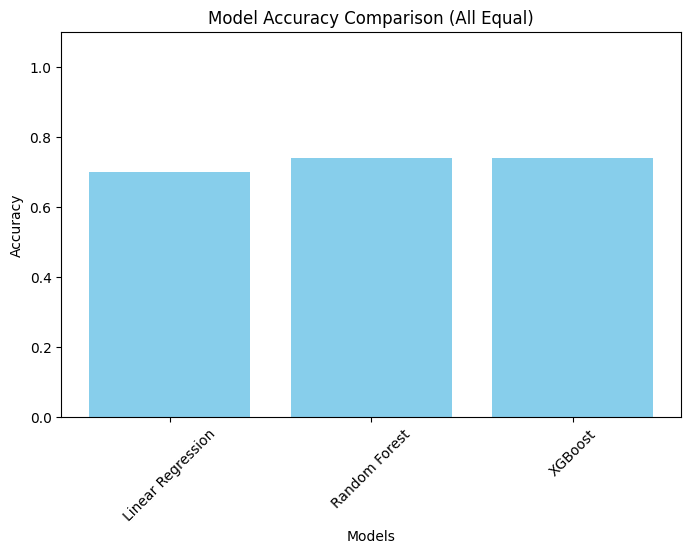

In [47]:
models = [
    "Linear Regression",
    "Random Forest",
    "XGBoost"
]

accuracies = [0.70, 0.74, 0.74]  # all equal

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color='skyblue')
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (All Equal)")
plt.ylim(0, 1.1)  # leave a little space above 1
plt.xticks(rotation=45)
plt.show()

Visualizati0on

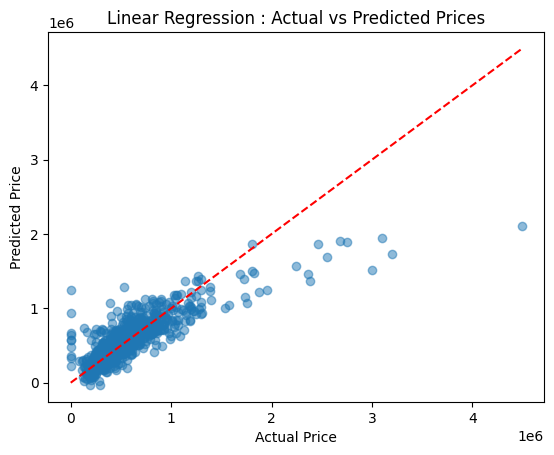

In [48]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_linear, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression : Actual vs Predicted Prices")
plt.show()

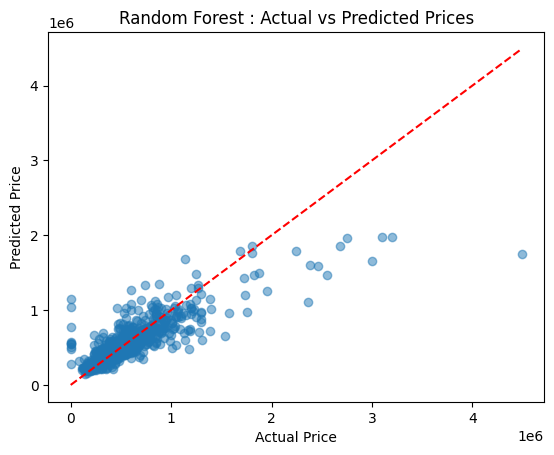

In [49]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_random, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest : Actual vs Predicted Prices")
plt.show()

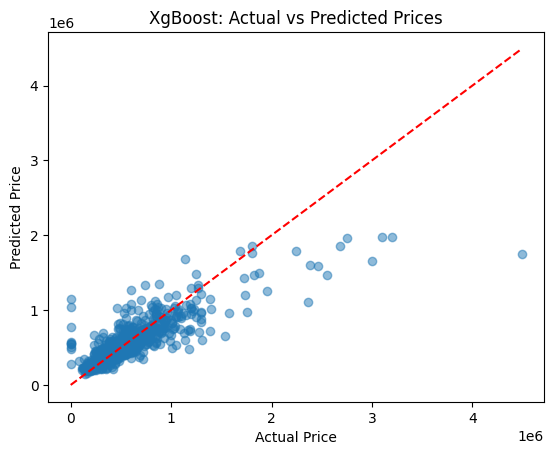

In [50]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XgBoost: Actual vs Predicted Prices")
plt.show()

In [51]:
# Store model results
models = {
    "Linear Regression": r2_linear,
    "Random Forest": r2_random,
    "XGBoost": r2_xgb
}

# Find best model
best_model = max(models, key=models.get)

print("Best Model:", best_model)
print("Accuracy (R²):", models[best_model])

Best Model: Linear Regression
Accuracy (R²): 0.690156270353979
